In [2]:
#ToN DATASET 0.03 FRACTION

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import shap
import random
import time
import networkx as nx
import tensorflow as tf
import shap
from contextlib import nullcontext  # <-- place at top-level once
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from tensorflow.keras.utils import plot_model
from tensorflow.keras.mixed_precision import global_policy, set_global_policy
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from imblearn.combine import SMOTEENN
from tensorflow.keras.mixed_precision import LossScaleOptimizer, set_global_policy
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report, auc
)
from sklearn.model_selection import train_test_split
from lime.lime_tabular import LimeTabularExplainer

print("All imported")


All imported


In [4]:
# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Optional: Limit to first GPU and set memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Num GPUs Available:  1


In [5]:
# Create plots directory
plots_dir = "/home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only."
os.makedirs(plots_dir, exist_ok=True) 

logging.basicConfig(level=logging.INFO)

In [6]:
# Function to load and prepare data
# def load_data(file_path):
#     data = pd.read_csv(file_path)
#     print("\n=== Dataset Overview ===")
#     print(data.head())
#     print("\n=== Dataset Columns and Data Types ===")
#     print(data.dtypes)
#     # print("\n=== Missing Values ===")
#     # print(data.isnull().sum())
#     print("\n=== Label Distribution ===")
#     print(data['Attack'].value_counts())
#     return data

# Encode categorical features
# def encode_categorical(balanced_data, categorical_columns):
#     encoder = LabelEncoder()
#     for col in categorical_columns:
#         balanced_data[col] = encoder.fit_transform(balanced_data[col])
#     return balanced_data



def encode_attack_label(df, label_col="Attack", benign_label="Benign"):
    df = df.copy()
    df[label_col] = (df[label_col] != benign_label).astype(int)  # Benign=0, DDoS=1
    return df




def clean_dataset(X):
    """
    Cleans the dataset by:
    - Replacing infinite values with NaN.
    - Replacing NaN values using the mean of each column.
    - Ensuring all values fit within the float32 range.
    """
    # Convert to DataFrame (if not already)
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    
    # Replace infinity with NaN
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Impute NaN values with column mean
    imputer = SimpleImputer(strategy="mean")
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Clip values to avoid float32 overflow (handling extremely large values)
    X_clipped = X_imputed.clip(lower=-1e10, upper=1e10)

    # # Final check for remaining infinite or NaN values
    # if X_imputed.isnull().sum().sum() > 0:
    #     raise ValueError("There are still NaN values present in the dataset.")
    # if np.isinf(X_imputed.values).sum() > 0:
    #     raise ValueError("There are still infinite values present in the dataset.")

    if X_clipped.isnull().sum().sum() > 0:
        raise ValueError("There are still NaN values present in the dataset.")
    if np.isinf(X_clipped.values).sum() > 0:
        raise ValueError("There are still infinite values present in the dataset.")


    
    print("Dataset successfully cleaned and prepared.")
    return X_clipped

# Balance the Dataset by Stratified Sampling
def balance_dataset_stratified(data, class_column='Attack', benign_label='Benign'):
    # Extract DDoS and benign samples
    ddos_samples = data[data[class_column] != benign_label]
    benign_samples = data[data[class_column] == benign_label]

    # Check for empty classes
    if len(benign_samples) == 0 or len(ddos_samples) == 0:
        print(f"Error: One of the classes has zero samples! Benign: {len(benign_samples)}, DDoS: {len(ddos_samples)}")
        return data

    # Always reduce the larger class to match the smaller class
    if len(benign_samples) > len(ddos_samples):
        print(f"Reducing Benign samples from {len(benign_samples)} to match DDoS count of {len(ddos_samples)}.")
        benign_samples = benign_samples.sample(n=len(ddos_samples), random_state=42)
    elif len(ddos_samples) > len(benign_samples):
        print(f"Reducing DDoS samples from {len(ddos_samples)} to match Benign count of {len(benign_samples)}.")
        ddos_samples = ddos_samples.sample(n=len(benign_samples), random_state=42)


    balanced_data = pd.concat([ddos_samples, benign_samples]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"\n=== Balanced Dataset ===")
    print(balanced_data[class_column].value_counts())

    return balanced_data


def check_two_class(y, name):
    u = np.unique(np.asarray(y))
    if len(u) < 2:
        raise ValueError(f"{name} is single-class: {u}. Retry split (seed) / adjust split settings.")
    print(f"[OK] {name} has both classes:", u)


def balance_after_split(df, y_col="Attack", random_state=42):
    """
    IMPORTANT: balance AFTER splitting (train only).
    This avoids leaking the same IP-driven structure into both train/test.
    """
    df = df.copy()
    c1 = df[df[y_col] == 1]
    c0 = df[df[y_col] == 0]
    if len(c0) == 0 or len(c1) == 0:
        return df

    n = min(len(c0), len(c1))
    c0s = c0.sample(n=n, random_state=random_state)
    c1s = c1.sample(n=n, random_state=random_state)
    out = pd.concat([c0s, c1s], axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out

In [7]:
# --- put near your other utils ---
def save_fig(path, dpi=300):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"[saved] {path}")

def plot_pca_variance(pca, plots_dir):
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    plt.title("Cumulative Explained Variance by PCA Components", fontsize=16)
    plt.xlabel("Number of Components", fontsize=14)
    plt.ylabel("Cumulative Explained Variance", fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    save_fig(os.path.join(plots_dir, "pca_variance_explained.png"))


def apply_pca(X_train, X_test, feature_columns, variance_ratio=0.95):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=variance_ratio)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    pca_loadings = pd.DataFrame(pca.components_, columns=feature_columns)
    top_features_per_component = [
        pca_loadings.iloc[i].abs().sort_values(ascending=False).index[0]
        for i in range(pca.n_components_)
    ]
    pca_feature_names = [f"{top_features_per_component[i]}" for i in range(len(top_features_per_component))]

    print(f"\n=== PCA Results ===")         
    print(f"Original Features: {X_train.shape[1]}, Reduced Features: {X_train_pca.shape[1]}")
    print(f"PCA Feature Names (mapped back to original features): {pca_feature_names}")

    plot_pca_variance(pca, plots_dir)
    return X_train_pca, X_test_pca, pca_feature_names, scaler, pca


def pad_and_reshape_pcs(X_pca, window_size):
    """
    X_pca: [batch, n_components] -> pad to multiple of window_size, then reshape to
           [batch, window_size, n_features_per_step]
    """
    n = X_pca.shape[1]
    padding = (window_size - (n % window_size)) % window_size
    if padding > 0:
        X_pca = np.pad(X_pca, ((0, 0), (0, padding)), mode="constant", constant_values=0)
    n_features_per_step = X_pca.shape[1] // window_size
    return X_pca.reshape(-1, window_size, n_features_per_step)


def make_predict_from_raw(model, scaler, pca, window_size):
    """
    Returns a function that:
    raw X  -> StandardScaler -> PCA -> pad/reshape  -> model.predict (GPU if available)
    """
    def predict_from_raw(X_raw):
        Xr = np.asarray(X_raw, dtype=np.float32)
        Xs = scaler.transform(Xr)
        Xp = pca.transform(Xs).astype(np.float32)
        Xpr = pad_and_reshape_pcs(Xp, window_size)
        return model.predict(Xpr, verbose=0).astype(np.float32)  # TF will use GPU
    return predict_from_raw


def run_shap_on_raw(model, scaler, pca, X_raw_sample, feature_names, window_size,
                    save_dir="shap_plots-BOT",
                    background_size=200,
                    max_display=20,
                    n_waterfalls=1,
                    dependence_feature=None,
                    interaction_feature=None):
    """
    Compute SHAP attributions in ORIGINAL feature space and SAVE plots.

    - model: trained Keras model (Transformer)
    - scaler, pca: fitted StandardScaler and PCA
    - X_raw_sample: np.array or DataFrame of RAW (cleaned) features to explain
    - feature_names: list of ORIGINAL feature names (len == X_raw_sample.shape[1])
    - window_size: same window_size used for training (for pad/reshape)
    - save_dir: directory to store figures
    - background_size: size of background subset for SHAP masker
    - max_display: max features shown in waterfall/summary
    - n_waterfalls: number of individual instance waterfall plots to save
    - dependence_feature / interaction_feature: names for dependence plot (optional)
    """

    os.makedirs(save_dir, exist_ok=True)

    # Ensure ndarray (float32)
    X_raw_sample = np.asarray(X_raw_sample, dtype=np.float32)
    rng = np.random.default_rng(42)
    bg_idx = rng.choice(X_raw_sample.shape[0], size=min(background_size, X_raw_sample.shape[0]), replace=False)
    bg = X_raw_sample[bg_idx]


    # raw -> scaler -> PCA -> pad/reshape -> predict
    def _predict_from_raw(X_raw):
        Xr = np.asarray(X_raw, dtype=np.float32)
        Xr_df = pd.DataFrame(Xr, columns=feature_names)
        Xs = scaler.transform(Xr_df)
        Xp = pca.transform(Xs).astype(np.float32)
        pad = (window_size - (Xp.shape[1] % window_size)) % window_size
        if pad > 0:
            Xp = np.pad(Xp, ((0, 0), (0, pad)), mode="constant", constant_values=0)
        Xpr = Xp.reshape(Xp.shape[0], window_size, Xp.shape[1] // window_size)
        return model.predict(Xpr, verbose=0).astype(np.float32)

    masker = shap.maskers.Independent(bg)
    explainer = shap.Explainer(_predict_from_raw, masker)
    shap_values = explainer(X_raw_sample)

    # ---------- Summary (beeswarm) ----------
    summary_path = os.path.join(save_dir, "shap_summary.png")
    plt.figure(figsize=(14, 10))
    shap.summary_plot(shap_values, X_raw_sample, feature_names=feature_names, show=False, max_display=max_display)
    plt.title("SHAP Summary (Original Features)")
    plt.tight_layout()
    plt.savefig(summary_path, dpi=400, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------- Summary (bar) ----------
    bar_path = os.path.join(save_dir, "shap_summary_bar.png")
    plt.figure(figsize=(14, 10))
    shap.summary_plot(shap_values, X_raw_sample, feature_names=feature_names,
                      plot_type="bar", show=False, max_display=max_display)
    plt.title("SHAP Summary – Bar (Original Features)")
    plt.tight_layout()
    plt.savefig(bar_path, dpi=400, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------- Dependence (optional) ----------
    dep_path = None
    if dependence_feature is not None and dependence_feature in feature_names:
        fi = feature_names.index(dependence_feature)
        ii = None
        if interaction_feature is not None and interaction_feature in feature_names:
            ii = feature_names.index(interaction_feature)
        dep_path = os.path.join(save_dir, f"shap_dependence_{dependence_feature}.png")
        plt.figure(figsize=(14, 10))
        shap.dependence_plot(
            ind=fi,
            shap_values=shap_values.values,     # (n_samples, n_features)
            features=X_raw_sample,
            feature_names=feature_names,
            interaction_index=ii,
            show=False
        )
        plt.title(f"SHAP Dependence: {dependence_feature}")
        plt.tight_layout()
        plt.savefig(dep_path, dpi=400, bbox_inches="tight")
        plt.show()
        plt.close()

    # ---------- Waterfall(s) for first n instances ----------
    waterfall_paths = []
    n_w = min(n_waterfalls, X_raw_sample.shape[0])
    for i in range(n_w):
        wf_path = os.path.join(save_dir, f"shap_waterfall_{i}.png")
        plt.figure(figsize=(12, 8))
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values[i].values,
                base_values=shap_values.base_values[i],
                feature_names=feature_names,
                data=X_raw_sample[i]
            ),
            max_display=max_display,
            show=False
        )
        plt.title(f"SHAP Waterfall – Sample {i}")
        plt.tight_layout()
        plt.savefig(wf_path, dpi=400, bbox_inches="tight")
        plt.show()
        plt.close()
        waterfall_paths.append(wf_path)

    print(f"Saved SHAP plots to: {save_dir}")
    return {
        "summary": summary_path,
        "bar": bar_path,
        "dependence": dep_path,
        "waterfalls": waterfall_paths,
        "values": shap_values
    }


def explain_with_lime_raw(model,
                          scaler,
                          pca,
                          window_size,
                          X_raw_sample,          # RAW (cleaned) features
                          feature_names,         # ORIGINAL feature names
                          class_names,
                          save_path_prefix="lime_explanation",
                          num_samples=5,
                          random_state=42):
    """
    LIME on ORIGINAL features. Internally applies scaler→PCA→pad/reshape→model.
    Saves each explanation as an HTML file.
    """
    os.makedirs(os.path.join(plots_dir, "lime"), exist_ok=True)


    # Ensure ndarray for LIME; keep a DataFrame copy for scaler with names
    if isinstance(X_raw_sample, pd.DataFrame):
        X_df = X_raw_sample[feature_names].reset_index(drop=True)
        X_np = X_df.values.astype(np.float32)
    else:
        X_np = np.asarray(X_raw_sample, dtype=np.float32)
        X_df = pd.DataFrame(X_np, columns=feature_names)

    # ---- prediction wrapper: RAW → scaler → PCA → pad/reshape → predict (2-class probs)
    def predict_from_raw_for_lime(X_raw_np):
        # Wrap as DataFrame to preserve feature names/order for scaler
        X_tmp_df = pd.DataFrame(np.asarray(X_raw_np, dtype=np.float32), columns=feature_names)
        Xs = scaler.transform(X_tmp_df)
        Xp = pca.transform(Xs).astype(np.float32)
        pad = (window_size - (Xp.shape[1] % window_size)) % window_size
        if pad > 0:
            Xp = np.pad(Xp, ((0, 0), (0, pad)), mode="constant", constant_values=0)
        X_seq = Xp.reshape(Xp.shape[0], window_size, Xp.shape[1] // window_size)
        p = model.predict(X_seq, verbose=0).astype(np.float32).ravel()
        # return 2-class probabilities for LIME
        return np.column_stack([1.0 - p, p])

    # LIME explainer on RAW features
    explainer = LimeTabularExplainer(
        training_data=X_np,
        feature_names=feature_names,
        class_names=class_names,
        mode="classification",
        discretize_continuous=True,
        random_state=random_state
    )

    # pick instances to explain
    rng = np.random.default_rng(random_state)
    idxs = rng.choice(X_np.shape[0], size=min(num_samples, X_np.shape[0]), replace=False)
    logging.info(f"LIME selected indices: {idxs.tolist()}")

    for i, idx in enumerate(idxs):
        exp = explainer.explain_instance(
            data_row=X_np[idx],
            predict_fn=predict_from_raw_for_lime,
            num_features=min(10, len(feature_names))
        )
        html_path = f"{save_path_prefix}_raw_sample_{idx}.html"
        exp.save_to_file(html_path)
        print(f"LIME (raw) explanation saved: {html_path}")


def plot_tsne(X, y, plots_dir):
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="viridis", alpha=0.7)
    plt.title("t-SNE Visualization After PCA", fontsize=16)
    plt.tight_layout()
    save_fig(os.path.join(plots_dir, "tsne_visualization.png"))


def plot_and_save_history(history, y_test, y_pred, y_pred_prob, plots_dir):
    os.makedirs(plots_dir, exist_ok=True)
    keys = set(history.history.keys())
    if not {"loss","val_loss"} <= keys or not {"accuracy","val_accuracy"} <= keys:
        print("History missing expected keys; skipping plots.")
        return

    # Loss
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Model Loss Over Epochs'); plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, alpha=0.5); plt.tight_layout()
    save_fig(os.path.join(plots_dir, "loss_plot.png"))

    # Accuracy
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title('Model Accuracy Over Epochs'); plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True, alpha=0.5); plt.tight_layout()
    save_fig(os.path.join(plots_dir, "accuracy_plot.png"))

    # Metrics to file
    from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc, precision_recall_curve
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    metrics_file_path = os.path.join(plots_dir, "evaluation_metrics.txt")
    with open(metrics_file_path, "w") as f:
        f.write(f"Precision: {precision:.6f}\nRecall: {recall:.6f}\nF1-Score: {f1:.6f}\n")
    print(f"[saved] {metrics_file_path}")

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.6f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
    plt.title('ROC Curve'); plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.legend(); plt.grid(True, alpha=0.5); plt.tight_layout()
    save_fig(os.path.join(plots_dir, "roc_curve.png"))

    # PR curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals, precision_vals)
    plt.title('Precision-Recall Curve'); plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.grid(True, alpha=0.5); plt.tight_layout()
    save_fig(os.path.join(plots_dir, "precision_recall_curve.png"))

    print(f"Precision={precision:.6f} Recall={recall:.6f} F1={f1:.6f} AUC={roc_auc:.6f}")

if "TransformerBlock" not in globals():
    @tf.keras.utils.register_keras_serializable(package="XNFT")
    class TransformerBlock(tf.keras.layers.Layer):
        def __init__(self, num_heads, ff_dim, input_dim=None, dropout_rate=0.1, **kwargs):
            super().__init__(**kwargs)
            self.num_heads = num_heads
            self.ff_dim = ff_dim
            self.input_dim_cfg = input_dim  # avoid clashing with Layer.input_dim
            self.dropout_rate = dropout_rate
    
            self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim)
            self.ffn = tf.keras.Sequential([
                tf.keras.layers.Dense(ff_dim, activation="relu"),
                tf.keras.layers.Dense(input_dim if input_dim else ff_dim)
            ])
            self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
            self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
            self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
            self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
    
        def call(self, inputs, training=None):
            if training is None:
                training = False
            attn_output = self.att(inputs, inputs)
            attn_output = self.dropout1(attn_output, training=training)
            out1 = self.layernorm1(inputs + attn_output)
            ffn_output = self.ffn(out1)
            ffn_output = self.dropout2(ffn_output, training=training)
            return self.layernorm2(out1 + ffn_output)
    
        def get_config(self):
            config = super().get_config()
            config.update({
                "num_heads": self.num_heads,
                "ff_dim": self.ff_dim,
                "input_dim": self.input_dim_cfg,
                "dropout_rate": self.dropout_rate,
            })
            return config
    
        @classmethod
        def from_config(cls, config):
            return cls(**config)
    

def build_flow_transformer(input_shape, num_heads, ff_dim, num_transformer_blocks, dropout_rate):
    inputs = tf.keras.Input(shape=input_shape, name="Flow_Input")
    x = inputs
    for _ in range(num_transformer_blocks):
        x = TransformerBlock(num_heads, ff_dim, input_dim=input_shape[-1], dropout_rate=dropout_rate)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="Binary_Output")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

### Hyperparameter Tuning ###


# def tune_hyperparameters(X_train, y_train, X_test, y_test, input_shape):
#     hyperparameter_grid = {
#         "num_heads": [2, 4, 8],
#         "ff_dim": [64, 128, 256],
#         "num_transformer_blocks": [2, 3, 4],
#         "dropout_rate": [0.1, 0.2, 0.3],
#         "learning_rate": [0.001, 0.0005, 0.0001],
#         "batch_size": [32, 64, 128]
#     }



# # def tune_hyperparameters(X_train, y_train, X_test, y_test, input_shape):
# #     hyperparameter_grid = {
# #         "num_heads": [2],
# #         "ff_dim": [64],
# #         "num_transformer_blocks": [2],
# #         "dropout_rate": [0.1],
# #         "learning_rate": [0.0005],
# #         "batch_size": [32]
# #     }
# # esting: num_heads=2, ff_dim=64, num_transformer_blocks=2, dropout_rate=0.1, learning_rate=0.0005, batch_size=32
    
#     results = []  # To store results for each combination
#     best_auc = 0
#     best_params = None

#     for num_heads in hyperparameter_grid["num_heads"]:
#         for ff_dim in hyperparameter_grid["ff_dim"]:
#             for num_transformer_blocks in hyperparameter_grid["num_transformer_blocks"]:
#                 for dropout_rate in hyperparameter_grid["dropout_rate"]:
#                     for learning_rate in hyperparameter_grid["learning_rate"]:
#                         for batch_size in hyperparameter_grid["batch_size"]:
#                             print(f"Testing: num_heads={num_heads}, ff_dim={ff_dim}, num_transformer_blocks={num_transformer_blocks}, dropout_rate={dropout_rate}, learning_rate={learning_rate}, batch_size={batch_size}")

#                             model = build_flow_transformer(input_shape, num_heads, ff_dim, num_transformer_blocks, dropout_rate)
#                             base_optimizer = Adam(learning_rate=learning_rate)
#                             optimizer = LossScaleOptimizer(base_optimizer)
#                             model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
                           
#                             early_stopping = EarlyStopping(
#                                 monitor="val_loss",
#                                 patience=3,
#                                 restore_best_weights=True
#                             )

#                             history = model.fit(
#                                 X_train, y_train,
#                                 batch_size=batch_size,
#                                 epochs=10,  # Fixed epochs for tuning
#                                 validation_data=(X_test, y_test),
#                                 callbacks=[early_stopping],
#                                 verbose=0
#                             )

#                             # y_pred = (model.predict(X_test) > 0.5).astype(int)
#                             # auc_score = roc_auc_score(y_test, y_pred)

#                             y_prob = model.predict(X_test, verbose=0).ravel()
#                             auc_score = roc_auc_score(y_test, y_prob)
                            
#                             accuracy = history.history['val_accuracy'][-1]

#                             # Append results to the list
#                             results.append({
#                                 "num_heads": num_heads,
#                                 "ff_dim": ff_dim,
#                                 "num_transformer_blocks": num_transformer_blocks,
#                                 "dropout_rate": dropout_rate,
#                                 "learning_rate": learning_rate,
#                                 "batch_size": batch_size,
#                                 "AUC": auc_score,
#                                 "Accuracy": accuracy
#                             })

#                             if auc_score > best_auc:
#                                 best_auc = auc_score
#                                 best_params = {
#                                     "num_heads": num_heads,
#                                     "ff_dim": ff_dim,
#                                     "num_transformer_blocks": num_transformer_blocks,
#                                     "dropout_rate": dropout_rate,
#                                     "learning_rate": learning_rate,
#                                     "batch_size": batch_size
#                                 }
#                             print(f"AUC: {auc_score:.6f}, Best AUC so far: {best_auc:.6f}")

#     # Convert results to a pandas DataFrame for better readability
#     results_df = pd.DataFrame(results)

#     # Printing the results to the console
#     print("\n=== Hyperparameter Tuning Results ===")
#     print(results_df)

#     # Save the DataFrame to a text file
#     results_txt_path = os.path.join(plots_dir, "Hyperparameter_Results.txt")
#     results_df.to_csv(results_txt_path, sep="\t", index=False)

#     print(f"Hyperparameter tuning results saved to: {results_txt_path}")
#     print("Available history keys:", history.history.keys())
    
#     print("Best Hyperparameters:", best_params)

#     return best_params, results_df


def tune_hyperparameters_random(
    X_train, y_train,
    X_val, y_val,
    input_shape,
    n_trials=25,
    seed=42
):
    rng = np.random.default_rng(seed)

    search_space = {
        "num_heads": [2, 4, 8],
        "ff_dim": [64, 128, 256],
        "num_transformer_blocks": [2, 3, 4],
        "dropout_rate": [0.1, 0.2, 0.3],
        "learning_rate": [0.001, 0.0005, 0.0001],
        "batch_size": [32, 64, 128]
    }

    results = []
    best_auc = -1.0
    best_params = None

    for t in range(n_trials):
        params = {k: rng.choice(v) for k, v in search_space.items()}
        print(f"\n[Trial {t+1}/{n_trials}] {params}")

        model = build_flow_transformer(
            input_shape=input_shape,
            num_heads=params["num_heads"],
            ff_dim=params["ff_dim"],
            num_transformer_blocks=params["num_transformer_blocks"],
            dropout_rate=params["dropout_rate"]
        )

        optimizer = LossScaleOptimizer(Adam(learning_rate=params["learning_rate"]))

        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
        )

        early_stopping = EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=2,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=10,
            batch_size=params["batch_size"],
            callbacks=[early_stopping],
            verbose=0
        )

        auc_score = float(np.max(history.history.get("val_auc", [0.0])))
        acc_score = float(np.max(history.history.get("val_accuracy", [0.0])))

        results.append({**params, "AUC": auc_score, "Accuracy": acc_score})

        if auc_score > best_auc:
            best_auc = auc_score
            best_params = params

        print(f"val_AUC={auc_score:.6f} | best={best_auc:.6f}")
        tf.keras.backend.clear_session()  # helps GPU memory

    results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)
    results_df.to_csv(os.path.join(plots_dir, "Hyperparameter_Results.txt"), sep="\t", index=False)

    print("\nBest Hyperparameters:", best_params)
    return best_params, results_df


def visualize_model_structure(model, save_path="model_structure.png"):
    """
    Visualizes the structure of the Transformer model and saves it to a file.

    Args:
        model (tf.keras.Model): The Transformer model to visualize.
        save_path (str): Path to save the visualization.
    """
    # Generate and save the model plot
    plot_model(
        model,
        to_file=save_path,
        show_shapes=True,
        show_layer_names=True,
        rankdir="TB",  # Top-to-Bottom layout
        dpi=400
    )
    plt.show()
    print(f"Model structure diagram saved to {save_path}")
    
    # Print the model summary to the console
    print("\nModel Summary:")
    model.summary()  # Print summary directly for better readability in console

    
# --- timing utils ---
def measure_training_time(model, fit_kwargs):
    t0 = time.perf_counter()
    hist = model.fit(**fit_kwargs)
    t1 = time.perf_counter()
    return hist, (t1 - t0)  # seconds


def measure_eval_time(model, X, y, batch_size=128):
    t0 = time.perf_counter()
    _ = model.evaluate(X, y, batch_size=batch_size, verbose=0)
    t1 = time.perf_counter()
    return (t1 - t0)  # seconds


def _dir_size_mb(path):
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return round(total / (1024**2), 3)

def measure_model_size(model, out_dir="model_artifacts"):
    os.makedirs(out_dir, exist_ok=True)

    # SavedModel
    sm_dir = os.path.join(out_dir, "savedmodel")
    if os.path.exists(sm_dir):
        import shutil; shutil.rmtree(sm_dir)
    model.save(sm_dir, include_optimizer=False)
    savedmodel_mb = _dir_size_mb(sm_dir)

    # H5
    h5_path = os.path.join(out_dir, "model.h5")
    model.save(h5_path, include_optimizer=False)
    h5_mb = round(os.path.getsize(h5_path) / (1024**2), 3)

    return {
        "savedmodel_path": sm_dir,
        "savedmodel_mb": savedmodel_mb,
        "h5_path": h5_path,
        "h5_mb": h5_mb,
        "trainable_params": int(model.count_params())
    }


def measure_inference_time(model, X_ref, batch_size=1, repeats=30, warmup=5, device=None):
    """
    Returns median per-sample latency (ms) and median per-batch latency (ms).
    """
    Xb = X_ref[:batch_size].astype(np.float32)
    ctx = tf.device(device) if device else nullcontext()

    with ctx:
        # warmup
        for _ in range(warmup):
            _ = model.predict(Xb, batch_size=batch_size, verbose=0)

        times = []
        for _ in range(repeats):
            t0 = time.perf_counter()
            _ = model.predict(Xb, batch_size=batch_size, verbose=0)
            t1 = time.perf_counter()
            times.append(t1 - t0)

    times = np.array(times)
    batch_p50_ms = np.percentile(times, 50) * 1000.0
    per_sample_p50_ms = batch_p50_ms / batch_size
    return {
        "device": device or "default",
        "batch_size": batch_size,
        "batch_latency_p50_ms": round(batch_p50_ms, 3),
        "per_sample_latency_p50_ms": round(per_sample_p50_ms, 3),
    }


In [8]:
def graph_based_flow_splitting(
    data,
    class_column="Attack",
    src_col="IPV4_SRC_ADDR",
    dst_col="IPV4_DST_ADDR",
    test_fraction=0.2,
    random_state=42,
    strict=True,          # keep only intra-split flows to avoid leakage
    make_plot=True
):
    """
    Graph-based split on IP nodes with leakage-safe flow assignment.

    Fixes:
    1) Node labels are aggregated (attack-dominant) instead of overwritten.
    2) Train/Test flows are disjoint:
       - train if (src AND dst) in train_nodes
       - test  if (src AND dst) in test_nodes
       - cross-split flows are dropped when strict=True
    """

    # --- Build graph (connectivity only) ---
    G = nx.Graph()
    edges = data[[src_col, dst_col]].dropna().values
    G.add_edges_from(edges)
    print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

    # --- Aggregate node labels (attack-dominant) ---
    # Assumes Attack already encoded to 0/1 (Benign=0, DDoS=1)
    node_label = {n: 0 for n in G.nodes()}
    for s, d, y in data[[src_col, dst_col, class_column]].dropna().itertuples(index=False, name=None):
        if int(y) == 1:              # any DDoS incident => node is DDoS
            node_label[s] = 1
            node_label[d] = 1

    benign_count = sum(1 for v in node_label.values() if v == 0)
    ddos_count   = sum(1 for v in node_label.values() if v == 1)
    print(f"Benign nodes: {benign_count}, DDoS nodes: {ddos_count}")
    if ddos_count == 0:
        raise ValueError("No DDoS nodes found after aggregation. Check label encoding.")

    node_list  = np.array(list(node_label.keys()))
    label_list = np.array([node_label[n] for n in node_list])

    # --- Stratified split on nodes ---
    train_nodes, test_nodes = train_test_split(
        node_list,
        test_size=test_fraction,
        stratify=label_list,
        random_state=random_state
    )
    train_nodes = set(train_nodes)
    test_nodes  = set(test_nodes)
    print(f"Train nodes: {len(train_nodes)}, Test nodes: {len(test_nodes)}")

    # --- Leakage-safe flow assignment ---
    src = data[src_col]
    dst = data[dst_col]

    in_train_src = src.isin(train_nodes)
    in_train_dst = dst.isin(train_nodes)
    in_test_src  = src.isin(test_nodes)
    in_test_dst  = dst.isin(test_nodes)

    if strict:
        train_mask = in_train_src & in_train_dst
        test_mask  = in_test_src  & in_test_dst
        cross_mask = (in_train_src & in_test_dst) | (in_test_src & in_train_dst)
        dropped = int(cross_mask.sum())
    else:
        # Not recommended for leakage claims; kept for debugging only.
        train_mask = in_train_src | in_train_dst
        test_mask  = in_test_src  | in_test_dst
        dropped = int((train_mask & test_mask).sum())

    train_data = data[train_mask].copy()
    test_data  = data[test_mask].copy()

    # --- Sanity checks ---
    assert set(train_data.index).isdisjoint(set(test_data.index)), "Row overlap between train/test!"
    assert train_nodes.isdisjoint(test_nodes), "Node overlap between train/test!"

    print("\n=== Train Set Label Distribution ===")
    print(train_data[class_column].value_counts())
    print("\n=== Test Set Label Distribution ===")
    print(test_data[class_column].value_counts())
    print(f"\nDropped cross-split flows (strict={strict}): {dropped}")

    # --- Optional visualization (small graphs only; otherwise heavy) ---
    if make_plot:
        try:
            # Sample nodes for plotting if huge
            max_nodes_plot = 3000
            H = G
            if G.number_of_nodes() > max_nodes_plot:
                sampled_nodes = list(np.random.default_rng(random_state).choice(
                    list(G.nodes()), size=max_nodes_plot, replace=False
                ))
                H = G.subgraph(sampled_nodes).copy()

            # color by node_label
            node_labels_H = {n: node_label.get(n, 0) for n in H.nodes()}
            color_map = ["red" if node_labels_H[n] == 1 else "green" for n in H.nodes()]
            size_map  = [120 if node_labels_H[n] == 1 else 40 for n in H.nodes()]

            pos = nx.spring_layout(H, seed=random_state, k=0.15, iterations=50)
            plt.figure(figsize=(12, 12))
            nx.draw_networkx_edges(H, pos, alpha=0.25, edge_color="gray")
            nx.draw_networkx_nodes(H, pos, node_color=color_map, node_size=size_map, alpha=0.9)
            plt.title("Graph-Based Flow Visualization (sampled if large)")
            plt.axis("off")
            save_path = os.path.join(plots_dir, "graph_publication.png")
            plt.tight_layout()
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.show()
            plt.close()
            print(f"Graph visualization saved to {save_path}.")
        except Exception as e:
            print(f"[warn] graph plot skipped: {e}")

    return train_data, test_data, {"dropped_cross_flows": dropped}

def graph_split_with_retries(
    data_enc,
    label_col="Attack",
    src_col="IPV4_SRC_ADDR",
    dst_col="IPV4_DST_ADDR",
    test_fraction=0.2,
    strict=True,
    seed_start=42,
    n_tries=20,
    min_test_flows=10000,
    min_test_ddos=500,
    make_plot_final=True
):
    """
    Tries multiple random seeds until:
      - test has BOTH classes
      - test is not tiny
      - test has enough DDoS samples
    """
    best = None
    best_score = -1

    for seed in range(seed_start, seed_start + n_tries):
        print(f"\n--- Graph split try seed={seed} ---")
        train_df, test_df, info = graph_based_flow_splitting(
            data_enc,
            class_column=label_col,
            src_col=src_col,
            dst_col=dst_col,
            test_fraction=test_fraction,
            random_state=seed,
            strict=strict,
            make_plot=False
        )

        vc = test_df[label_col].value_counts().to_dict()
        test_total = len(test_df)
        test_ddos  = int(vc.get(1, 0))
        test_ben   = int(vc.get(0, 0))

        ok = (test_total >= min_test_flows) and (test_ddos >= min_test_ddos) and (test_ben > 0)
        print(f"seed={seed} test_flows={test_total} (benign={test_ben}, ddos={test_ddos}) ok={ok}")

        score = test_ddos * 10 + test_total
        if score > best_score:
            best_score = score
            best = (seed, train_df, test_df, info)

        if ok:
            # final split with plot enabled
            if make_plot_final:
                train_df, test_df, info = graph_based_flow_splitting(
                    data_enc,
                    class_column=label_col,
                    src_col=src_col,
                    dst_col=dst_col,
                    test_fraction=test_fraction,
                    random_state=seed,
                    strict=strict,
                    make_plot=True
                )
            return seed, train_df, test_df, info

    print("[WARN] No seed met thresholds. Using best available split.")
    seed, train_df, test_df, info = best
    if make_plot_final:
        train_df, test_df, info = graph_based_flow_splitting(
            data_enc,
            class_column=label_col,
            src_col=src_col,
            dst_col=dst_col,
            test_fraction=test_fraction,
            random_state=seed,
            strict=strict,
            make_plot=True
        )
    return seed, train_df, test_df, info

In [9]:
import pandas as pd

def load_data(file_path, sample_fraction=1, chunksize=1_000_000):
    chunks = []

    for chunk in pd.read_csv(file_path, chunksize=chunksize):
        filtered = chunk[chunk['Attack'].isin(['Benign', 'ddos'])]
        chunks.append(filtered)
  
    df = pd.concat(chunks, ignore_index=True)

    print("\n=== Missing Values ===")
    print(df.isnull().sum())
    print("\n=== Label Distribution ===")
    print(df['Attack'].value_counts())

    # if sample_fraction < 1.0:
    #     df = df.sample(frac=sample_fraction, random_state=42)
          
    # print("\n=== Label Distribution ===")
    # print(data['Attack'].value_counts()

    return df

# def load_data(file_path):
#     data = pd.read_csv(file_path)
#     print("\n=== Dataset Overview ===")
#     print(data.head())
#     print("\n=== Dataset Columns and Data Types ===")
#     print(data.dtypes)
#     # print("\n=== Missing Values ===")
#     # print(data.isnull().sum())
#     print("\n=== Label Distribution ===")
#     print(data['Attack'].value_counts())
#     return data

In [10]:
with tf.device('/GPU:0'):
# Main Function
    def main(sample_fraction=1):
        file_path = "/home/g_kirubavathi/Amal/1_XNFT_R1/R2/NF-ToN-IoT-v2.csv"
        data = load_data(file_path)
        
        print("NF-ToN-IoT-v2")

    
        if sample_fraction < 1.0:
            data = data.sample(frac=sample_fraction, random_state=42)
            label_col = "Attack"
            print("After sampling:", data.shape)
            print("Label counts after sampling:\n", data[label_col].value_counts())
       

        # Keep raw IP strings for graph splitting; NEVER use IPs as features
        src_col = "IPV4_SRC_ADDR"
        dst_col = "IPV4_DST_ADDR"
        label_col = "Attack"
        
        # Only encode label (Attack) here; do NOT encode IPs
        categorical_columns = [label_col]   # <-- changed
        
        # Define feature columns BEFORE encoding anything else:
        DROP_COLS = [label_col, src_col, dst_col]
        feature_columns = [
            c for c in data.columns
            if c not in DROP_COLS and pd.api.types.is_numeric_dtype(data[c])
        ]
        print("Num features (excluding label+IPs):", len(feature_columns))


        # -------------------------------
        # Reviewer-driven feature removal
        # -------------------------------
        EXCLUDE_FEATURES = {
            "DNS_QUERY_ID",
            "DNS_TTL_ANSWER", "MIN_TTL", "MAX_TTL", "DNS_QUERY_TYPE", "Label"                
        }
        
        # Optional ablation (only if you decide to test sensitivity)
        # EXCLUDE_FEATURES |= {"MIN_TTL", "MAX_TTL"}
        
        feature_columns = [c for c in feature_columns if c not in EXCLUDE_FEATURES]
        
        print("Removed features:", sorted(EXCLUDE_FEATURES))
        print("Num features after removal:", len(feature_columns))
        
       
    
        class_names = ["Benign", "DDoS"]
      
        
       # -------------------------------
        # 1) Encode label FIRST (do NOT balance yet)
        # -------------------------------
        data_enc = encode_attack_label(data, label_col=label_col, benign_label="Benign")
        check_two_class(data_enc[label_col].values, "FULL CIC (encoded)")
        
        # -------------------------------
        # 2) Graph split with retries (avoids single-class / tiny test)
        # -------------------------------
        seed_used, train_data, test_data, split_info = graph_split_with_retries(
            data_enc,
            label_col=label_col,
            src_col=src_col,
            dst_col=dst_col,
            test_fraction=0.2,
            strict=True,
            seed_start=42,
            n_tries=20,
            min_test_flows=10000,
            min_test_ddos=500,
            make_plot_final=True
        )
        print("Split info:", split_info)
        print("Seed used:", seed_used)

        total_flows = len(data_enc)
        dropped = split_info.get("dropped_cross_flows", 0)
        print(f"Dropped cross flows: {dropped} ({100*dropped/total_flows:.2f}%) out of {total_flows}")

        
        # -------------------------------
        # 3) Balance ONLY TRAIN (recommended)
        #    Keep test unbalanced for realism
        # -------------------------------
        train_data = balance_after_split(train_data, y_col=label_col, random_state=seed_used)
        print("\n[Train balanced] label counts:")
        print(train_data[label_col].value_counts())
        
        # Optional: if (and only if) you want balanced test too, uncomment:
        # test_data = balance_after_split(test_data, y_col=label_col, random_state=seed_used)
        
        # -------------------------------
        # 4) Final sanity checks
        # -------------------------------
        check_two_class(train_data[label_col].values, "Train (after balancing)")
        check_two_class(test_data[label_col].values, "Test")
                

        # -------------------------------
        # 3.5) Create VALIDATION split from TRAIN only (fix test leakage)
        # -------------------------------
        train_inner, val_inner = train_test_split(
            train_data,
            test_size=0.2,
            stratify=train_data[label_col],
            random_state=seed_used
        )
        
        print("\n[TrainInner] label counts:")
        print(train_inner[label_col].value_counts())
        print("\n[ValInner] label counts:")
        print(val_inner[label_col].value_counts())
        
        check_two_class(train_inner[label_col].values, "TrainInner")
        check_two_class(val_inner[label_col].values, "ValInner")
        
        # Feature Extraction: TrainInner / ValInner / Test
        X_train = train_inner[feature_columns]; y_train = train_inner[label_col].values
        X_val   = val_inner[feature_columns];   y_val   = val_inner[label_col].values
        X_test  = test_data[feature_columns];   y_test  = test_data[label_col].values
        

        print("y_train unique:", np.unique(y_train))
        print("y_test unique :", np.unique(y_test))
    

        X_train_cleaned = clean_dataset(X_train)
        X_val_cleaned   = clean_dataset(X_val)
        X_test_cleaned  = clean_dataset(X_test)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_cleaned).astype(np.float32)
        X_val_scaled   = scaler.transform(X_val_cleaned).astype(np.float32)
        X_test_scaled  = scaler.transform(X_test_cleaned).astype(np.float32)
        
        pca = PCA(n_components=0.95, random_state=seed_used)  # or fixed components
        X_train_pca = pca.fit_transform(X_train_scaled).astype(np.float32)
        X_val_pca   = pca.transform(X_val_scaled).astype(np.float32)
        X_test_pca  = pca.transform(X_test_scaled).astype(np.float32)
        
        print("PCA components:", X_train_pca.shape[1])


        # t-SNE on a small sample only (otherwise too slow / memory heavy)
        tsne_n = min(5000, X_train_pca.shape[0])
        idx = np.random.default_rng(42).choice(X_train_pca.shape[0], size=tsne_n, replace=False)
        plot_tsne(X_train_pca[idx], np.asarray(y_train)[idx], plots_dir)


        window_size = 8
        X_train_pca_seq = pad_and_reshape_pcs(X_train_pca, window_size)
        X_val_pca_seq   = pad_and_reshape_pcs(X_val_pca,   window_size)
        X_test_pca_seq  = pad_and_reshape_pcs(X_test_pca,  window_size)


        print(f"X_train shape after PCA, padding, and reshaping: {X_train_pca_seq.shape}")
        print(f"X_test shape after PCA, padding, and reshaping: {X_test_pca_seq.shape}")

        # Hyperparameter Tuning
        try:
            # Hyperparameter tuning
            best_params, tuning_results = tune_hyperparameters_random(X_train_pca_seq, y_train,X_val_pca_seq,   y_val,input_shape=X_train_pca_seq.shape[1:],n_trials=25,seed=seed_used)
            print("Best parameters found:", best_params)
        except Exception as e:
            print(f"Error during hyperparameter tuning: {e}")
            return
        
        # Build and train final model using PCA features
        model = build_flow_transformer(
            input_shape=X_train_pca_seq.shape[1:],
            num_heads=best_params["num_heads"],
            ff_dim=best_params["ff_dim"],
            num_transformer_blocks=best_params["num_transformer_blocks"],
            dropout_rate=best_params["dropout_rate"]
        )
        
        # Visualize and save the model structure
        visualize_model_structure(model, save_path=os.path.join(plots_dir, "transformer_model_structure.png"))
        
        optimizer=LossScaleOptimizer(Adam(learning_rate=best_params["learning_rate"]))
        
        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
        )
        
        early_stopping = EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            restore_best_weights=True
        )
        

        print("Sanity check:")
        print("  X_train_pca_seq:", X_train_pca_seq.shape)
        print("  y_train:", len(y_train))
        print("  X_test_pca_seq:", X_test_pca_seq.shape)
        print("  y_test:", len(y_test))

        
        assert X_train_pca_seq.shape[0] == len(y_train), "Mismatch: X_train vs y_train"
        assert X_test_pca_seq.shape[0]  == len(y_test),  "Mismatch: X_test vs y_test"

        print("SHAPES:")
        print("  train_data:", train_data.shape, " test_data:", test_data.shape)
        print("  X_train_cleaned:", X_train_cleaned.shape, " y_train:", len(y_train))
        print("  X_test_cleaned:",  X_test_cleaned.shape,  " y_test:",  len(y_test))
        print("  X_train_pca:", X_train_pca.shape, " X_test_pca:", X_test_pca.shape)
        print("  X_train_pca_seq:", X_train_pca_seq.shape, " X_test_pca_seq:", X_test_pca_seq.shape)
        print("  X_val_pca_seq:", X_val_pca_seq.shape, " y_val:", len(y_val))

        assert X_val_pca_seq.shape[0] == len(y_val), "Mismatch: X_val_pca_seq vs y_val"
        assert X_train_pca_seq.shape[0] == len(y_train), "Mismatch: X_train_pca_seq vs y_train"
        assert X_test_pca_seq.shape[0]  == len(y_test),  "Mismatch: X_test_pca_seq vs y_test"
    

                # --- TRAIN with timing ---
        fit_kwargs = dict(
            x=X_train_pca_seq, y=y_train,
            batch_size=best_params["batch_size"],
            epochs=50,
            validation_data=(X_val_pca_seq, y_val), 
            callbacks=[early_stopping],
            verbose=1
        )
        history, train_time_s = measure_training_time(model, fit_kwargs)
        
            # --- EVALUATE timing ---
        eval_time_s = measure_eval_time(model, X_test_pca_seq, y_test, batch_size=best_params["batch_size"])

        # --- PREDICTIONS (probabilities) ---
        y_pred_prob_pca = model.predict(X_test_pca_seq)
        y_pred_pca = (y_pred_prob_pca > 0.5).astype(int)
        
        print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob_pca.ravel()))
        print("Classification Report:\n", classification_report(y_test, y_pred_pca))
                
        # Updated Call to Plot and Save History with PCA data
        plot_and_save_history(history, y_test, y_pred_pca, y_pred_prob_pca, plots_dir)    

        cm = confusion_matrix(y_test, y_pred_pca)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Benign", "DDoS"], yticklabels=["Benign", "DDoS"])
        plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.tight_layout()
        save_fig(os.path.join(plots_dir, "confusion_matrix.png"))
        print("Confusion Matrix:\n", cm)

        # --- MODEL SIZE ---
        sizes = measure_model_size(model, out_dir=os.path.join(plots_dir, "bench_min"))
        print(f"Params: {sizes['trainable_params']:,}")
        print(f"Model size — SavedModel: {sizes['savedmodel_mb']} MB, H5: {sizes['h5_mb']} MB")
        
        # --- INFERENCE LATENCY (bs=1, CPU and GPU if present) ---
        lat_cpu = measure_inference_time(model, X_test_pca_seq, batch_size=1, repeats=30, warmup=5, device="/CPU:0")
        print(f"CPU bs=1 → per-sample p50: {lat_cpu['per_sample_latency_p50_ms']} ms")
        
        if tf.config.list_physical_devices('GPU'):
            lat_gpu = measure_inference_time(model, X_test_pca_seq, batch_size=1, repeats=30, warmup=5, device="/GPU:0")
            print(f"GPU bs=1 → per-sample p50: {lat_gpu['per_sample_latency_p50_ms']} ms")
        
        # --- PAPER-STYLE TABLE ROW ---
        timing_row = {
            "Dataset": "NF-ToN-IoT-v2",
            "Training Time (s)": round(train_time_s, 2),
            "Evaluation Time (s)": round(eval_time_s, 2),
            "Avg Inference Time (ms)": lat_cpu["per_sample_latency_p50_ms"],
            "Max / Min Inference (ms)": "— / —"  # fill if you want max/min with a loop
        }
        timing_csv = os.path.join(plots_dir, "timings", "timing_summary.csv")
        os.makedirs(os.path.dirname(timing_csv), exist_ok=True)
        (pd.DataFrame([timing_row])).to_csv(timing_csv, index=False)
        print(f"[saved] {timing_csv}")

            
        # Use the actual top contributing features from PCA instead of hardcoded names
        # primary_feature = pca_feature_names[0] if pca_feature_names else "Component 1"
        # interaction_feature = pca_feature_names[1] if len(pca_feature_names) > 1 else "Component 2"
    
        X_raw_sample = X_test_cleaned.sample(n=min(50, len(X_test_cleaned)), random_state=42).values

        shap_outputs = run_shap_on_raw(
            model=model,
            scaler=scaler,
            pca=pca,
            X_raw_sample = X_test_cleaned.sample(n=min(5, len(X_test_cleaned)), random_state=42).values,   # RAW, cleaned
            feature_names=feature_columns,              # ORIGINAL feature names
            window_size=window_size,
            save_dir=os.path.join(plots_dir, "shap"),
            background_size=200,
            max_display=20,
            n_waterfalls=1,                             # increase if you want more instances
            dependence_feature=None,                    # or a specific feature name
            interaction_feature=None
        )

        # Use RAW, CLEANED test features and ORIGINAL names
        explain_with_lime_raw(
            model=model,
            scaler=scaler,
            pca=pca,
            window_size=window_size,
            X_raw_sample=X_test_cleaned,          # DataFrame or np.array of RAW features
            feature_names=feature_columns,        # ORIGINAL feature names
            class_names=["Benign", "DDoS"],
            save_path_prefix=os.path.join(plots_dir, "lime", "lime_explanation"),
            num_samples=10
        )
        
        # ---------- Usage ----------
        # Use your real test tensor (same shape as model input)
        # Example: X_test_pca_seq already prepared in your code
        # sizes = measure_model_size(model, out_dir="plots/bench_min")
        sizes = measure_model_size(model, out_dir=os.path.join(plots_dir, "bench_min"))
        print(f"Params: {sizes['trainable_params']:,}")
        print(f"Model size — SavedModel: {sizes['savedmodel_mb']} MB, H5: {sizes['h5_mb']} MB")
        
        # Inference latency (change batch_size as needed; bs=1 is “real-time”)
        lat_cpu = measure_inference_time(model, X_test_pca_seq, batch_size=1, repeats=30, warmup=5, device="/CPU:0")
        print(f"CPU bs=1 → per-sample p50: {lat_cpu['per_sample_latency_p50_ms']} ms")
        
        # If a GPU is available, measure there too
        if tf.config.list_physical_devices('GPU'):
            lat_gpu = measure_inference_time(model, X_test_pca_seq, batch_size=1, repeats=30, warmup=5, device="/GPU:0")
            print(f"GPU bs=1 → per-sample p50: {lat_gpu['per_sample_latency_p50_ms']} ms")


        print("Dataset: NF-ToN-IoT-v2")

        return {
        "model": model,
        "scaler": scaler,
        "pca": pca,
        "window_size": window_size,
        "feature_columns": feature_columns
        }
        

2026-02-09 12:58:25.054586: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-09 12:58:27.703607: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14621 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0



=== Missing Values ===
IPV4_SRC_ADDR                  0
L4_SRC_PORT                    0
IPV4_DST_ADDR                  0
L4_DST_PORT                    0
PROTOCOL                       0
L7_PROTO                       0
IN_BYTES                       0
IN_PKTS                        0
OUT_BYTES                      0
OUT_PKTS                       0
TCP_FLAGS                      0
CLIENT_TCP_FLAGS               0
SERVER_TCP_FLAGS               0
FLOW_DURATION_MILLISECONDS     0
DURATION_IN                    0
DURATION_OUT                   0
MIN_TTL                        0
MAX_TTL                        0
LONGEST_FLOW_PKT               0
SHORTEST_FLOW_PKT              0
MIN_IP_PKT_LEN                 0
MAX_IP_PKT_LEN                 0
SRC_TO_DST_SECOND_BYTES        0
DST_TO_SRC_SECOND_BYTES        0
RETRANSMITTED_IN_BYTES         0
RETRANSMITTED_IN_PKTS          0
RETRANSMITTED_OUT_BYTES        0
RETRANSMITTED_OUT_PKTS         0
SRC_TO_DST_AVG_THROUGHPUT      0
DST_TO_SRC_AVG_THRO

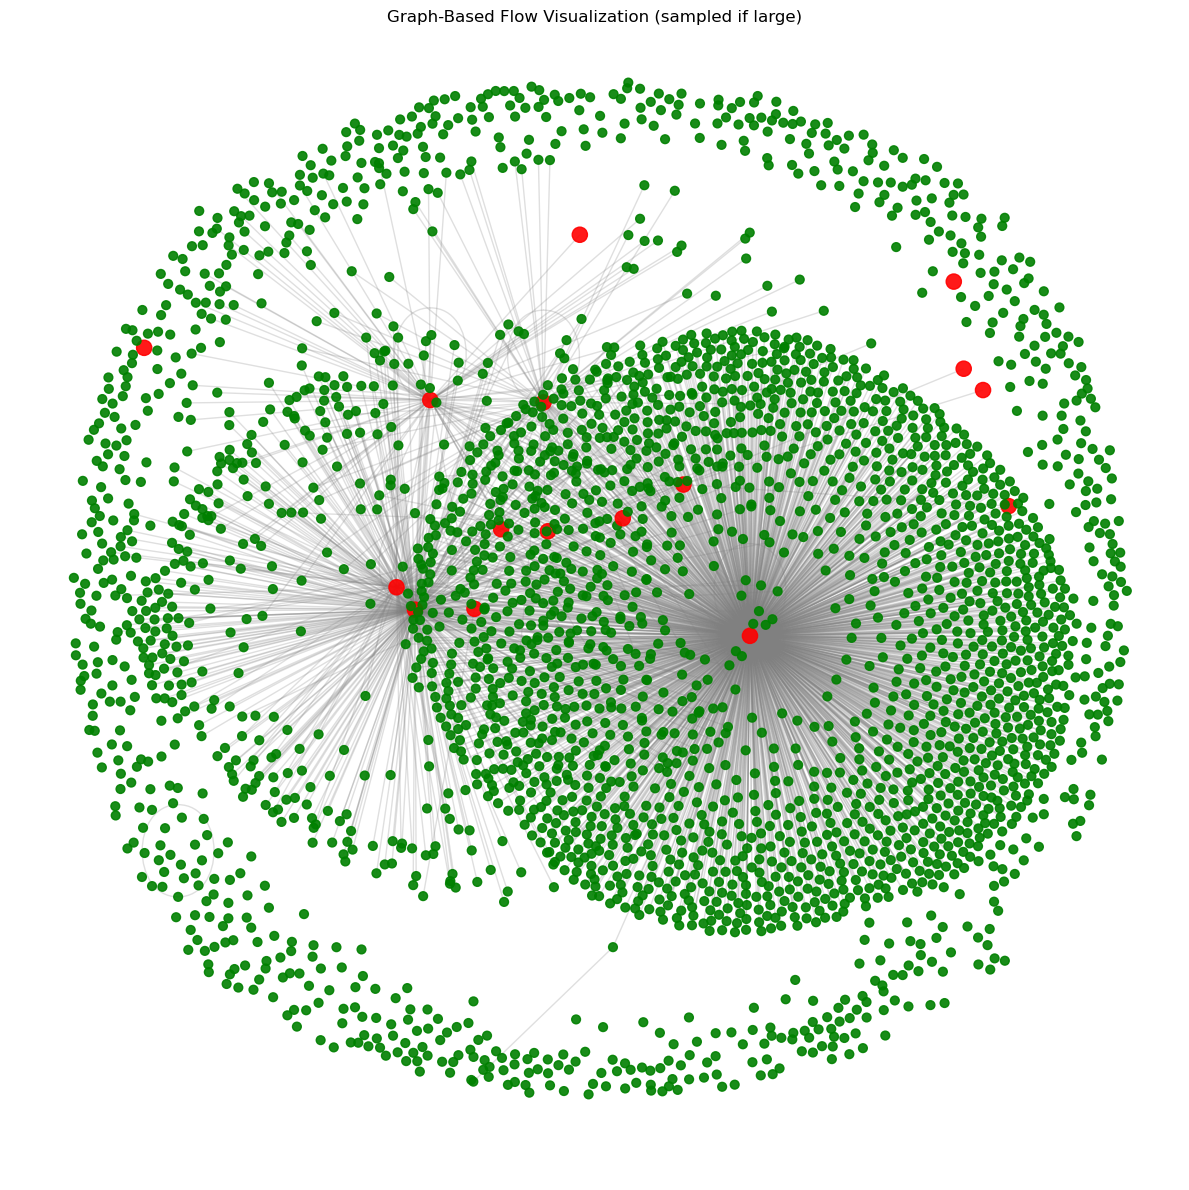

Graph visualization saved to /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./graph_publication.png.
Split info: {'dropped_cross_flows': 195528}
Seed used: 43
Dropped cross flows: 195528 (24.06%) out of 812570

[Train balanced] label counts:
Attack
1    146076
0    146076
Name: count, dtype: int64
[OK] Train (after balancing) has both classes: [0 1]
[OK] Test has both classes: [0 1]

[TrainInner] label counts:
Attack
1    116861
0    116860
Name: count, dtype: int64

[ValInner] label counts:
Attack
0    29216
1    29215
Name: count, dtype: int64
[OK] TrainInner has both classes: [0 1]
[OK] ValInner has both classes: [0 1]
y_train unique: [0 1]
y_test unique : [0 1]



A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Dataset successfully cleaned and prepared.
Dataset successfully cleaned and prepared.
Dataset successfully cleaned and prepared.



A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


PCA components: 23


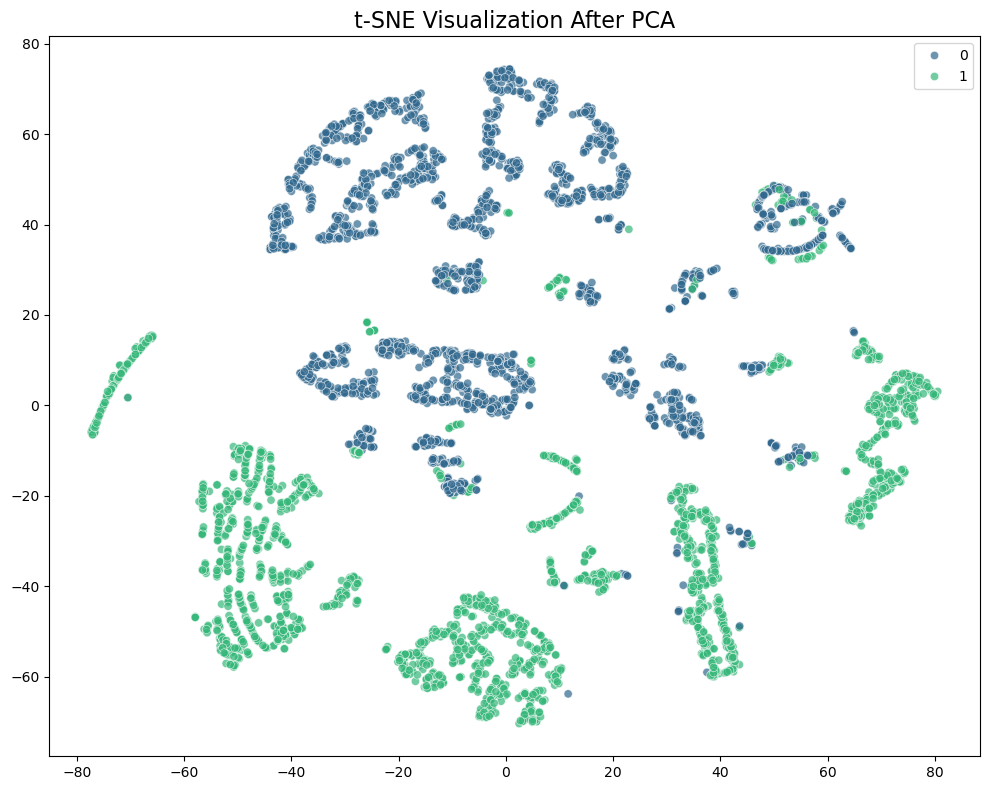

[saved] /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./tsne_visualization.png
X_train shape after PCA, padding, and reshaping: (233721, 8, 3)
X_test shape after PCA, padding, and reshaping: (24585, 8, 3)

[Trial 1/25] {'num_heads': 4, 'ff_dim': 128, 'num_transformer_blocks': 3, 'dropout_rate': 0.1, 'learning_rate': 0.0005, 'batch_size': 32}
val_AUC=0.999481 | best=0.999481

[Trial 2/25] {'num_heads': 2, 'ff_dim': 256, 'num_transformer_blocks': 3, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'batch_size': 32}
val_AUC=0.999200 | best=0.999481

[Trial 3/25] {'num_heads': 8, 'ff_dim': 256, 'num_transformer_blocks': 3, 'dropout_rate': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
val_AUC=0.999387 | best=0.999481

[Trial 4/25] {'num_heads': 4, 'ff_dim': 128, 'num_transformer_blocks': 2, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 128}
val_AUC=0.999125 | best=0.999481

[Trial 5/25] {'num_heads': 2, 'ff_dim': 64, 'num_transformer_blocks': 4, 'dropout_rate': 0.1, 'le

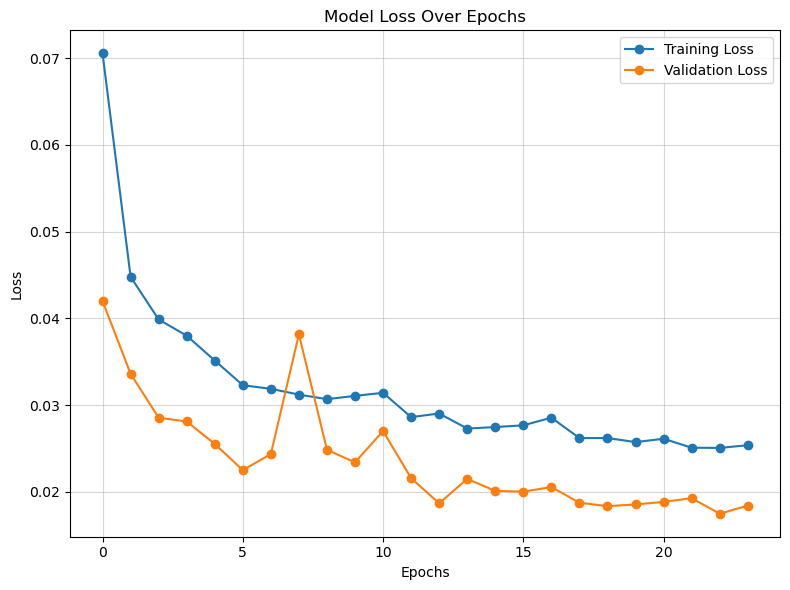

[saved] /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./loss_plot.png


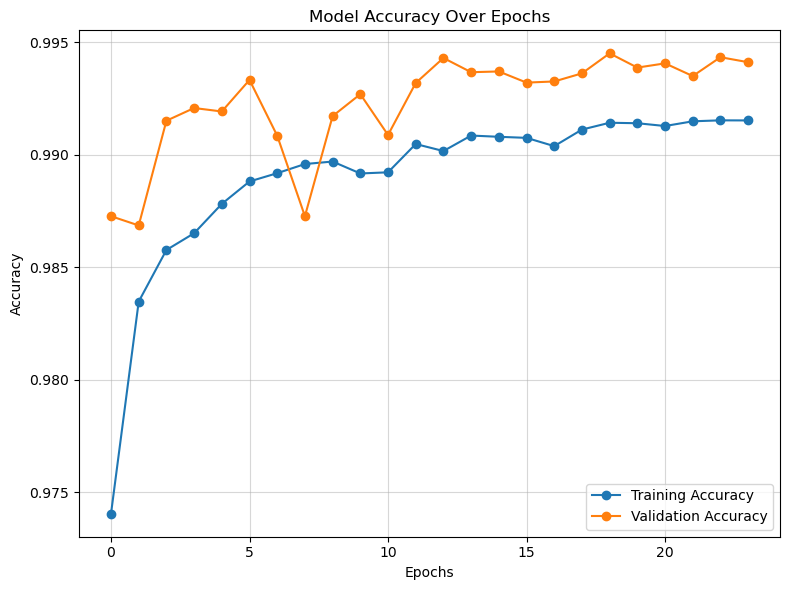

[saved] /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./accuracy_plot.png
[saved] /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./evaluation_metrics.txt


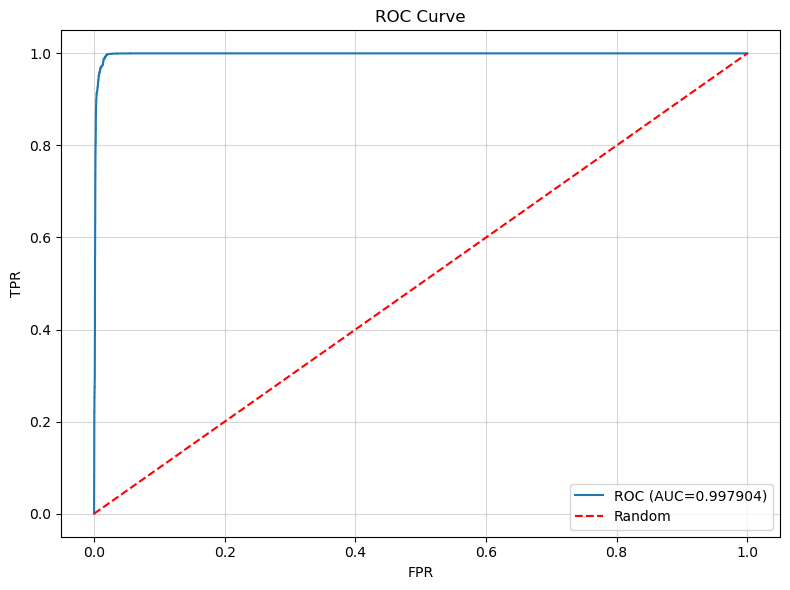

[saved] /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./roc_curve.png


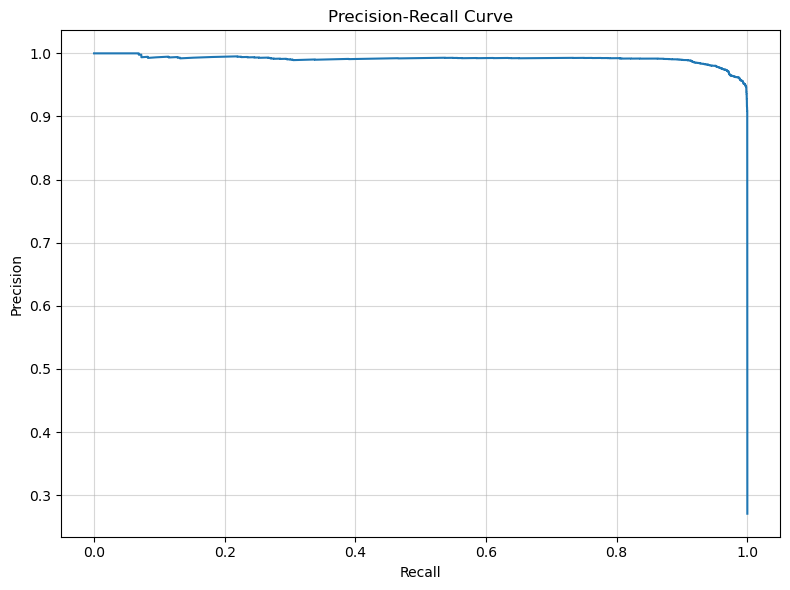

[saved] /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./precision_recall_curve.png
Precision=0.972973 Recall=0.968586 F1=0.970774 AUC=0.997904


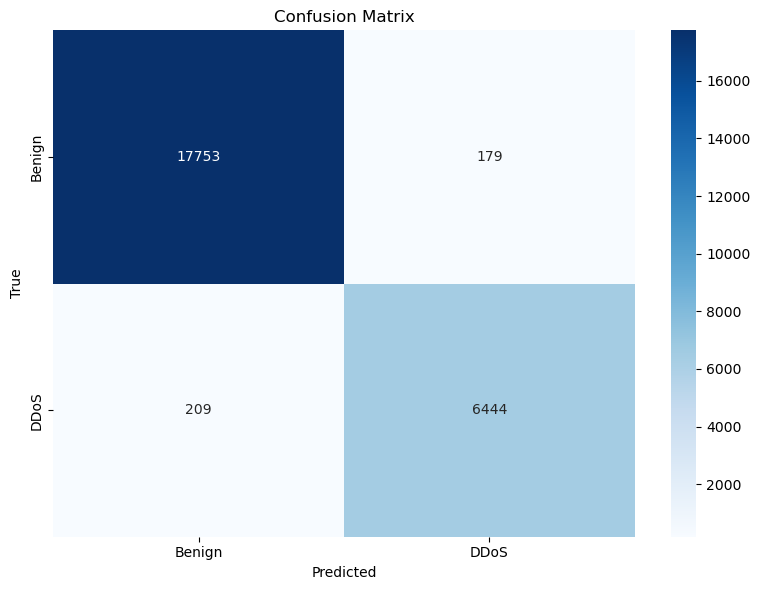

[saved] /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./confusion_matrix.png
Confusion Matrix:
 [[17753   179]
 [  209  6444]]


2026-02-10 10:39:34.364375: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./bench_min/savedmodel/assets


INFO:tensorflow:Assets written to: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./bench_min/savedmodel/assets


Params: 8,823
Model size — SavedModel: 1.046 MB, H5: 0.103 MB
CPU bs=1 → per-sample p50: 169.927 ms
GPU bs=1 → per-sample p50: 149.022 ms
[saved] /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./timings/timing_summary.csv


PermutationExplainer explainer: 6it [00:23,  4.76s/it]                                                     


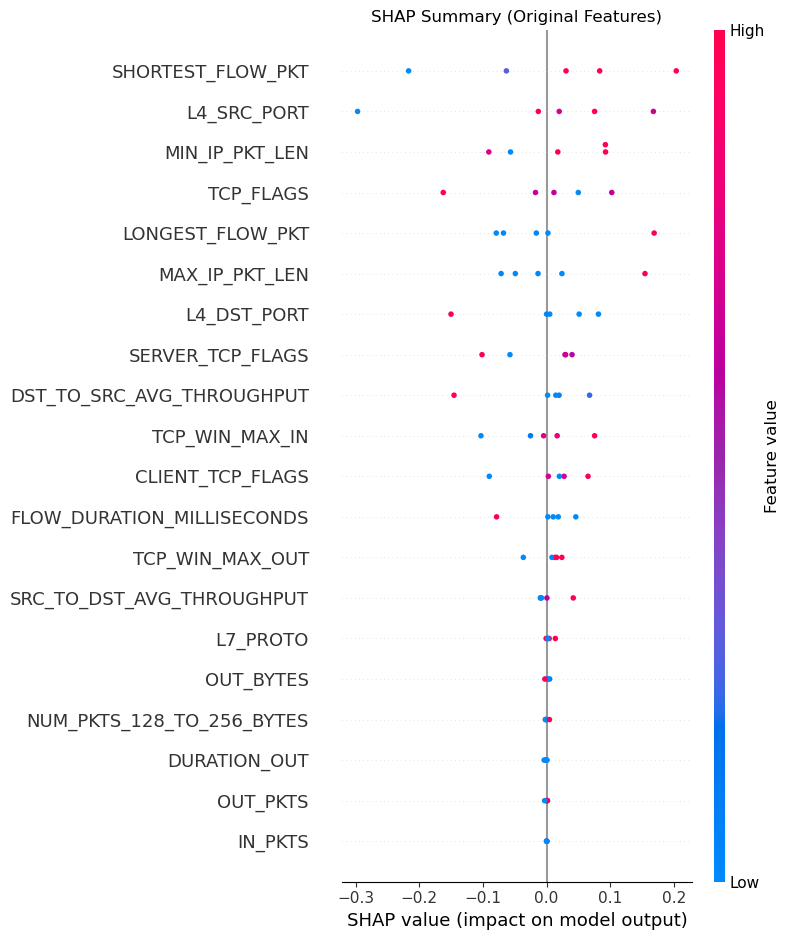

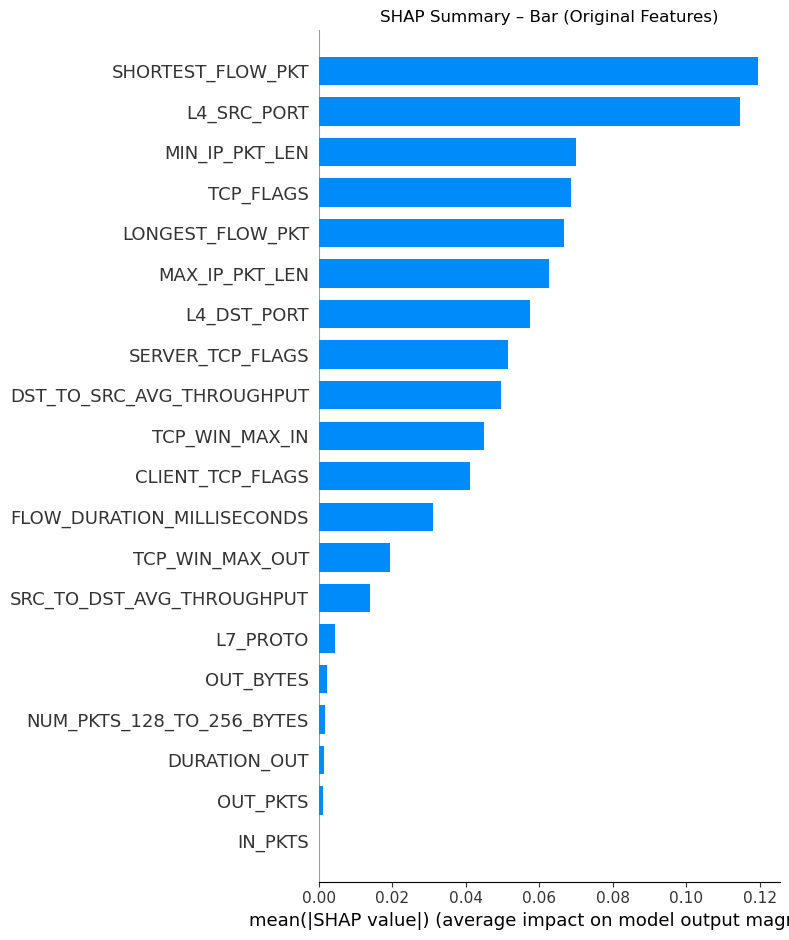

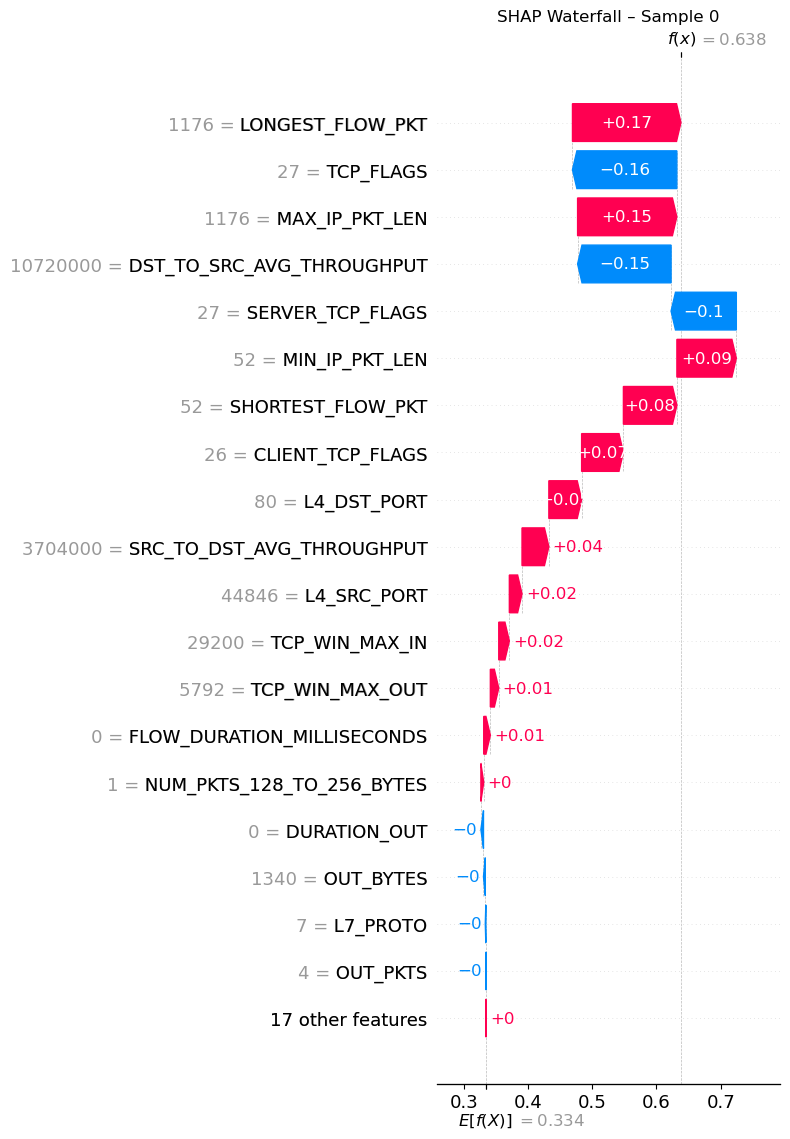

Saved SHAP plots to: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./shap


INFO:root:LIME selected indices: [2112, 19021, 2193, 16088, 10787, 10643, 17143, 2315, 4952, 21105]


LIME (raw) explanation saved: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./lime/lime_explanation_raw_sample_2112.html
LIME (raw) explanation saved: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./lime/lime_explanation_raw_sample_19021.html
LIME (raw) explanation saved: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./lime/lime_explanation_raw_sample_2193.html
LIME (raw) explanation saved: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./lime/lime_explanation_raw_sample_16088.html
LIME (raw) explanation saved: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./lime/lime_explanation_raw_sample_10787.html
LIME (raw) explanation saved: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./lime/lime_explanation_raw_sample_10643.html
LIME (raw) explanation saved: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./lime/lime_explanation_raw_sample_17143.html
LIME (raw) explanation saved: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only

INFO:tensorflow:Assets written to: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./bench_min/savedmodel/assets


INFO:tensorflow:Assets written to: /home/g_kirubavathi/Amal/1_XNFT_R1/R2/plots_r2_ToN_Only./bench_min/savedmodel/assets


Params: 8,823
Model size — SavedModel: 1.046 MB, H5: 0.103 MB
CPU bs=1 → per-sample p50: 173.936 ms
GPU bs=1 → per-sample p50: 150.469 ms
Dataset: NF-ToN-IoT-v2


In [11]:
with tf.device('/GPU:0'):
    out = main(sample_fraction=0.1)
    model = out["model"]
    scaler = out["scaler"]
    pca = out["pca"]
    window_size = out["window_size"]
    feature_columns = out["feature_columns"]